## Set up data and model objects

In [1]:
import pandas as pd
import numpy as np
import os

import mudata as md
import anndata as ad
import perturbo
import seaborn as sns
import pyro
from scipy.stats import norm
import matplotlib.pyplot as plt
import torch

torch.cuda.device_count()

/usr/local/lib/python3.10/dist-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/usr/local/lib/python3.10/dist-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


1

In [2]:
import scvi
scvi.settings.seed = 0 

Global seed set to 0


Set training configuration and access to data

In [3]:

data_dir = "/work/data/SHARED_DATA/gasperini_2019"
batch_size=4096 # multiple of 64

# smoke_test=True # only run a tiny subset of genes
smoke_test=False # run full analysis

if torch.cuda.is_available():
    accelerator = "gpu"
    print("training using GPU")
else:
    accelerator = "cpu"
    print("training using CPU")

if smoke_test:
    selected_guides = ["TMED10_TSS|1", "TMED10_TSS|2"]
    selected_genes = ["ACTG1"]
else:
    selected_guides = None
    selected_genes = None


training using GPU


### Load the data
(50k cells, takes ~30 seconds)

In [4]:
mdata = md.read_h5mu(f'{data_dir}/gasperini_pilot_highMOI.h5mu')
# batch_size=None
mdata

MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [5]:
sceptre_df = pd.read_csv(f"{data_dir}/sceptre_results-2023_01_13.csv")
sceptre_df = sceptre_df.rename(columns={"gRNA_id": "guide", "gene_id": "gene", "z_value":"SCEPTRE_z_value","p_value":"SCEPTRE_p_value"})

if not smoke_test or selected_genes is None:
    selected_genes = sceptre_df["gene"].unique()
if not smoke_test or selected_guides is None:
    selected_guides = sceptre_df["guide"].unique()

print(len(selected_genes), len(selected_guides))
# sceptre_df.query("guide=='GATA2_TSS|1'")


5859 1243


In [6]:
np.where(mdata['grna'][:,"scrambled_9|2"].varm["element_targeted"].values)
mdata['grna'][:,"scrambled_9|2"].varm["element_targeted"].columns[1560]

'scrambled_9'

In [7]:
sceptre_df.query("pair_type=='negative_control'")

,gene,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change
21272,Metazoa_SRP,random_1|1,negative_control,0.225595,-0.745345,-0.331922
21273,OR2G6,random_1|1,negative_control,0.985559,2.585539,0.942606
21274,SLC3A2,random_1|1,negative_control,0.874096,1.930871,0.153495
21275,PTPN11,random_1|1,negative_control,0.685826,0.454581,0.040252
21276,CORO7,random_1|1,negative_control,0.847094,1.114626,0.175454
...,...,...,...,...,...,...
22261,SNORD60,scrambled_9|2,negative_control,0.950426,1.765242,0.708387
22262,DCAKD,scrambled_9|2,negative_control,0.488787,-0.149950,-0.027133
22263,RNF213-AS1,scrambled_9|2,negative_control,0.847978,1.018406,0.507472
22264,NAPB,scrambled_9|2,negative_control,0.696904,0.508168,0.149431


In [8]:
grna_subset = mdata.mod['grna'][:,selected_guides].copy()
rna_subset = mdata.mod['rna'][:,selected_genes].copy()
mdata = md.MuData({'rna':rna_subset, 'grna':grna_subset})
mdata

MuData object with n_obs × n_vars = 47964 × 7102
  2 modalities
    rna:	47964 x 5859
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 1243
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [9]:
mdata['grna'].varm['element_targeted']

,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,scrambled_24,scrambled_25,scrambled_2,scrambled_3,scrambled_4,scrambled_5,scrambled_6,scrambled_7,scrambled_8,scrambled_9
ACTB_TSS|1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scrambled_7|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
scrambled_8|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_8|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_9|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Register data with perturbo

In [10]:
perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="bath_number",
    library_size_key="library_size",
    continuous_covariates_keys=["log_total_guide_count", "log_number_of_detected_genes"],
    # var_by_element_key="element_tested",
    perturb_by_element_key="element_targeted",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbo.PERTURBO(mdata, likelihood='lnnb', fit_lib_size=False)
model.view_anndata_setup()


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


INFO     Using column names from columns of adata.varm['element_targeted']                                         


Anndata setup with scvi-tools version 1.0.2.

Setup via `PERTURBO.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'perturbation_layer': None,
│   'batch_key': 'bath_number',
│   'var_by_element_key': None,
│   'perturb_by_element_key': 'element_targeted',
│   'library_size_key': 'library_size',
│   'size_factor_key': None,
│   'continuous_covariates_keys': ['log_total_guide_count', 'log_number_of_detected_genes'],
│   'categorical_covariates_keys': None,
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'}
}

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   6   │
│         n_cells         │ 47964 │
│ n_extra_continuous_covs │   2   │
│     n_perturbations     │ 1243  │
│   n_targeted_elements   │ 1561  │
│         n_vars          │ 5859  │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │      adata.mod['grna'].varm['element_targeted']      │
└───────────────────────┴──────────────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['bath_number'] │     1      │          0          │
│                          │     2      │          1          │
│                          │     3      │          2          │
│                          │     4      │          3          │
│                          │     5      │          4          │
│                          │     6      │          5          │
└──────────────────────────┴────────────┴─────────────────────┘

    extra_continuous_covs State Registry     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃              Source Location              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    adata.obs['log_total_guide_count']     │
│ adata.obs['log_number_of_detected_genes'] │
└───────────────────────────────────────────┘

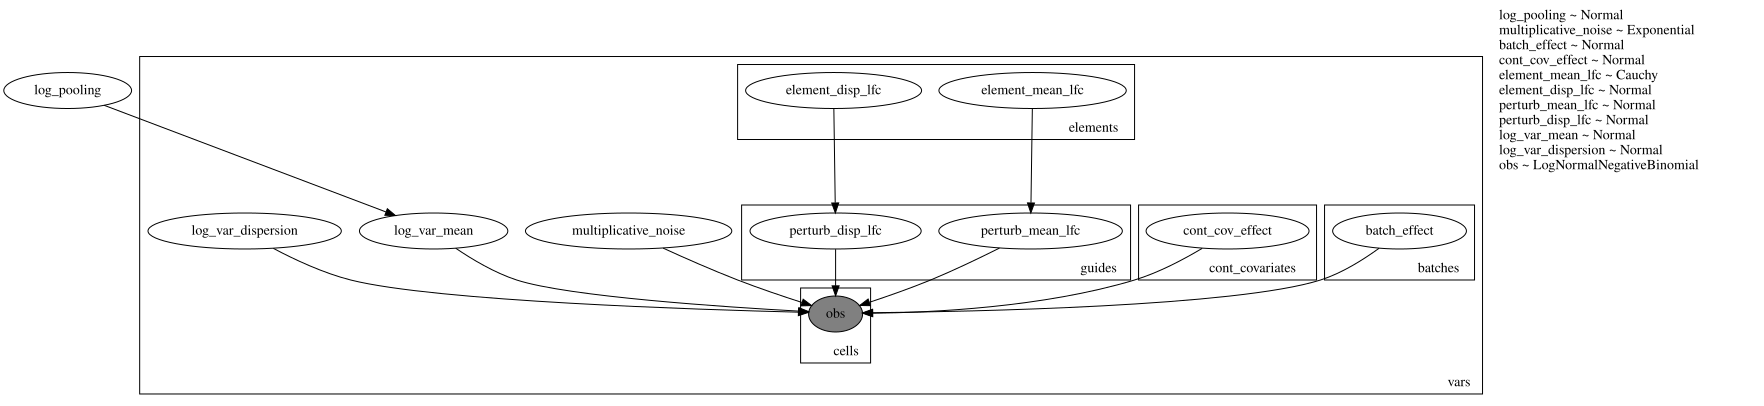

In [11]:
# requires graphviz to be installed
model.render_model()

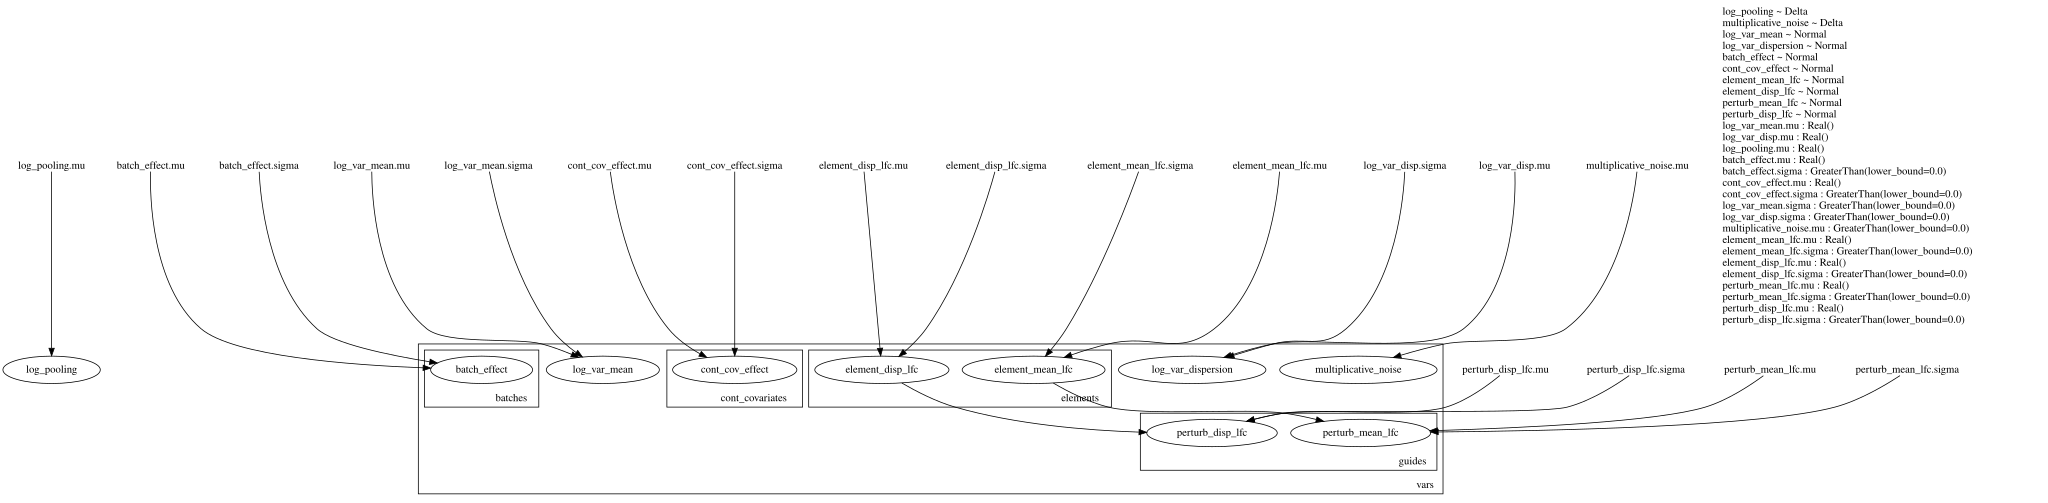

In [12]:
model.render_guide()

### Train the model

In [13]:
# burn-in
pyro.clear_param_store()
# plan_kwargs = {'optim': pyro.optim.ClippedAdam(dict(lr=0.1, lrd=0.96))}
# model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)
# model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)


In [14]:
## fine-tune
# plan_kwargs = {'optim': pyro.optim.ClippedAdam(dict(lr=0.1, lrd=0.99))}
# model.train(20, lr=0.1, batch_size=1024, use_gpu=use_gpu)
# model.train(100, lr=0.03, batch_size=1024, use_gpu=use_gpu)


In [15]:
model.train(25, lr=0.01, batch_size=512, accelerator=accelerator) 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/configuration_validator.py:68: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 25/25: 100%|██████████| 25/25 [03:52<00:00,  9.49s/it, v_num=1, elbo_train=2.37e+8]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 25/25: 100%|██████████| 25/25 [03:52<00:00,  9.28s/it, v_num=1, elbo_train=2.37e+8]


In [16]:
model.train(25, lr=0.003, batch_size=512, accelerator=accelerator)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/configuration_validator.py:68: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 25/25: 100%|██████████| 25/25 [03:58<00:00,  9.67s/it, v_num=1, elbo_train=2.27e+8]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 25/25: 100%|██████████| 25/25 [03:58<00:00,  9.53s/it, v_num=1, elbo_train=2.27e+8]


In [17]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)

log_var_mean.mu torch.Size([5859])
log_var_disp.mu torch.Size([5859])
log_pooling.mu torch.Size([1])
tensor([0.1500], device='cuda:0', requires_grad=True)
batch_effect.mu torch.Size([6, 5859])
batch_effect.sigma torch.Size([6, 5859])
cont_cov_effect.mu torch.Size([3, 5859])
cont_cov_effect.sigma torch.Size([3, 5859])
log_var_mean.sigma torch.Size([5859])
log_var_disp.sigma torch.Size([5859])
multiplicative_noise.mu torch.Size([5859])
element_mean_lfc.mu torch.Size([1561, 5859])
element_mean_lfc.sigma torch.Size([1561, 5859])
element_disp_lfc.mu torch.Size([1561, 5859])
element_disp_lfc.sigma torch.Size([1561, 5859])
perturb_mean_lfc.mu torch.Size([1243, 5859])
perturb_mean_lfc.sigma torch.Size([1243, 5859])
perturb_disp_lfc.mu torch.Size([1243, 5859])
perturb_disp_lfc.sigma torch.Size([1243, 5859])


In [104]:
# lfc_threshold = 0.1 # ~ at least 10% upreg
lfc_threshold = 0 # nonzero change
# gene_index=45


variance_eqtl = False

# lfc_cov_tril = pyro.get_param_store()['perturb_lfc.scale_tril']
# lfc_cov = lfc_cov_tril @ lfc_cov_tril.transpose(dim0=-1, dim1=-2)

### UNIVARIATE HYPOTHESIS TESTING
guide_by_element = mdata['grna'].varm['element_targeted'].values
element_mu = guide_by_element @ pyro.get_param_store()['element_mean_lfc.mu'].detach().cpu().numpy()
element_sigma = guide_by_element @ pyro.get_param_store()['element_mean_lfc.sigma'].detach().cpu().numpy()

q_mu = element_mu + pyro.get_param_store()['perturb_mean_lfc.mu'].detach().cpu().numpy()
q_sigma = np.sqrt(element_sigma**2 + pyro.get_param_store()['perturb_mean_lfc.sigma'].detach().cpu().numpy()**2)

assert q_mu.shape == q_sigma.shape
perturb_z_scores = q_mu/q_sigma
# p_val_1 = norm.sf(-lfc_threshold, loc=q_mu, scale=q_sigma)
# p_val_2 = norm.cdf(lfc_threshold, loc=q_mu, scale=q_sigma)
# perturb_p_vals = np.minimum(p_val_1, p_val_2)*2

perturb_p_vals=norm.sf(-lfc_threshold, loc=q_mu, scale=q_sigma)

In [105]:
np.isnan(perturb_z_scores).any()

False

convert matrix into long df of results

In [106]:
def make_long_df(mat, value_name):
    return (
        pd.DataFrame(data=mat, columns=selected_genes, index=selected_guides)
        .melt(var_name="gene", value_name=value_name, ignore_index=False)
        .reset_index(names="guide")
    )

scpower_df = pd.merge(
    make_long_df(perturb_z_scores, "z_value"),
    make_long_df(perturb_p_vals, "p_value")
)


In [107]:
scpower_df.sort_values('p_value')

,guide,gene,z_value,p_value
5824092,TMEM14C_TSS|2,TMEM14C,-32.254250,1.533490e-228
6008087,TSPO_TSS|1,TSPO,-29.347382,1.290307e-189
5836525,TMEM167A_TSS|1,TMEM167A,-27.947639,3.521238e-172
5824091,TMEM14C_TSS|1,TMEM14C,-27.584286,8.588217e-168
2079719,EIF4H_TSS|1,EIF4H,-27.318199,1.289334e-164
...,...,...,...,...
3131978,chr11:33966182-33966205|1,ATG16L2,11.480313,1.000000e+00
1673664,SMARCC1_TSS|1,CALB1,10.408700,1.000000e+00
1673665,SMARCC1_TSS|2,CALB1,10.290401,1.000000e+00
1983447,chr11:33966182-33966205|2,B2M,12.300268,1.000000e+00


In [108]:
merge_df = scpower_df.merge(sceptre_df).assign(is_target=lambda x: x['guide'].str.split('_', expand=True)[0]==x['gene'].str.replace(r"-AS[0-9]*$","", regex=True))


if not smoke_test:
  assert len(merge_df)==len(sceptre_df)
merge_df.sort_values("SCEPTRE_p_value")

,guide,gene,z_value,p_value,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change,is_target
18859,TMSB4X_TSS|2,TMSB4X,-10.727834,3.767083e-27,positive_control,2.220446e-16,-12.484713,-0.512579,True
19352,UBE2S_TSS|1,UBE2S,-8.912165,2.502286e-19,positive_control,2.220446e-16,-13.188147,-0.636552,True
13475,MTHFD2L_TSS|1,MTHFD2L,-17.273741,3.708737e-67,positive_control,2.220446e-16,-16.659531,-0.955546,True
19874,ZRANB2_TSS|1,ZRANB2,-9.648311,2.498607e-22,positive_control,2.220446e-16,-11.648026,-0.955711,True
18829,TMEM98_TSS|2,TMEM98,-12.308619,4.070231e-35,positive_control,2.220446e-16,-11.388380,-0.695734,True
...,...,...,...,...,...,...,...,...,...
14022,VAPA_TSS|2,RAB31,4.770916,9.999991e-01,positive_control,1.000000e+00,7.044067,0.495025,False
3883,CCND2_TSS|1,CCND2-AS1,9.348388,1.000000e+00,positive_control,1.000000e+00,9.731796,1.868678,True
13996,NDUFV2_TSS|2,NDUFV2-AS1,9.663080,1.000000e+00,positive_control,1.000000e+00,10.676218,1.141676,True
21835,random_2|2,CSNK2A2,2.861803,9.978938e-01,negative_control,1.000000e+00,3.297314,0.244607,False


## Visualize hits



In [109]:
from sklearn.linear_model import LinearRegression

reg_x=(merge_df[["z_value"]].values)
reg_y=(merge_df[["SCEPTRE_z_value"]].values)
reg = LinearRegression(fit_intercept=False).fit(reg_x, reg_y)
print("slope:", reg.coef_[0,0])
print("R^2:", reg.score(reg_x, reg_y))


slope: 1.0882778
R^2: 0.8932751241267691


<Axes: xlabel='SCEPTRE_z_value', ylabel='SCEPTRE_p_value'>

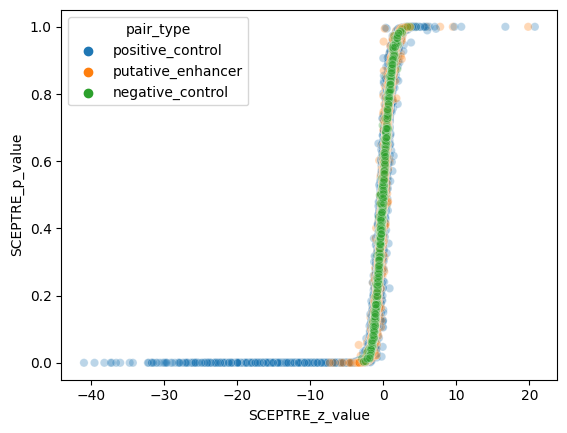

In [110]:
sns.scatterplot(merge_df, x='SCEPTRE_z_value', y='SCEPTRE_p_value', hue='pair_type', alpha=0.3)

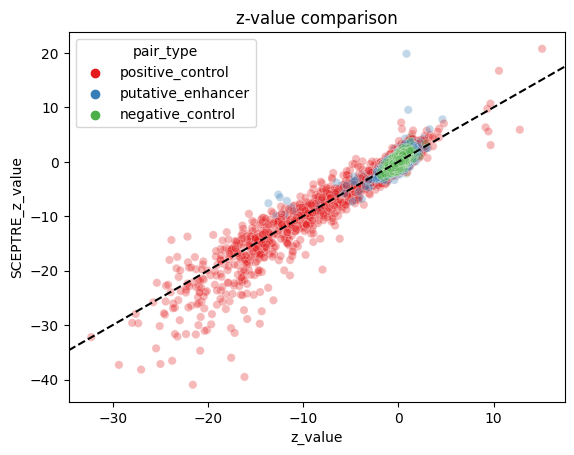

In [111]:
plt.title("z-value comparison")
sns.scatterplot(merge_df, x='z_value', y='SCEPTRE_z_value', hue='pair_type', alpha=0.3, palette='Set1')
plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
plt.show()


## Interactive data visualization
Need to subset and clip the data so that we can plot interactively

(1e-21, 2)

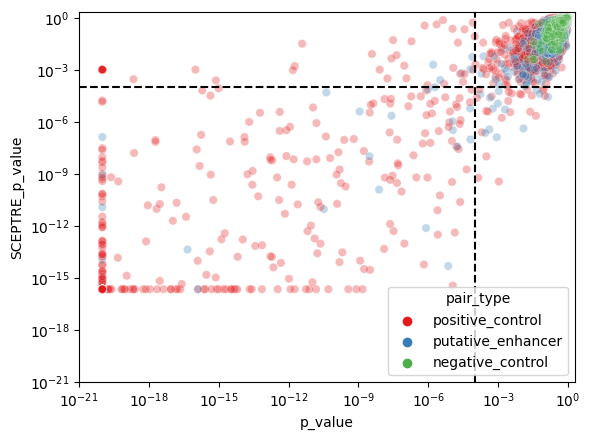

In [112]:
min_p_value = 1e-20
merge_df['p_value'] = np.maximum(merge_df['p_value'], min_p_value)

sns.scatterplot(merge_df, x="p_value", y="SCEPTRE_p_value", hue="pair_type", alpha=0.3, palette="Set1")
# plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
plt.axhline(1e-4, c='black', linestyle='dashed')
plt.axvline(1e-4,  c='black', linestyle='dashed')

plt.loglog()
# plt.legend()
plt.xlim(1e-21, 2)
plt.ylim(1e-21, 2)

In [113]:
subset_results = merge_df.query("p_value<0.01 or SCEPTRE_p_value < 0.01").copy()
# subset_results = merge_df.query("p_value<1e-5")
subset_results['p_value'] = np.maximum(subset_results['p_value'], min_p_value)
subset_results

,guide,gene,z_value,p_value,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change,is_target
89,EIF4EBP1_TSS|1,Y_RNA,-0.908722,1.817484e-01,positive_control,9.082759e-03,-2.026480,-1.123034,False
401,chr10:120850440-120850463|2,Y_RNA,-1.719732,4.274061e-02,putative_enhancer,7.397573e-03,-1.890200,-inf,False
495,chr11:65239420-65239443|1,Y_RNA,-0.701888,2.413745e-01,putative_enhancer,9.857491e-03,-1.894889,-1.704986,False
627,chr15:64187339-64187362|1,Y_RNA,-0.638918,2.614382e-01,putative_enhancer,8.587112e-03,-1.898975,-inf,False
679,ACTB_TSS|1,ACTB,-11.365073,1.000000e-20,positive_control,2.220446e-16,-18.059480,-0.430690,True
...,...,...,...,...,...,...,...,...,...
21485,chr14:69216270-69216293|2,SUSD6,-0.961438,1.681660e-01,putative_enhancer,2.727040e-03,-2.384127,-2.048698,False
21870,random_22|1,PPFIA1,-1.802424,3.573937e-02,negative_control,3.721259e-03,-2.667942,-0.220873,False
22027,scrambled_11|2,PHACTR2,-1.868612,3.083839e-02,negative_control,5.442752e-03,-2.484966,-0.251919,False
22036,scrambled_13|1,FKBP14,-1.192271,1.165775e-01,negative_control,2.792471e-03,-2.688553,-0.277200,False


In [130]:
pos_controls = merge_df.query("pair_type=='positive_control'")
pos_controls=pos_controls[~pos_controls['gene'].str.contains("-AS")] # remove alt start sites
pos_controls=pos_controls.assign(
    perturbo_rank=lambda x: x.groupby('guide')['p_value'].rank(),
    perturbo_p_rank=lambda x: x.groupby('guide')['z_value'].rank(),
    SCEPTRE_p_rank=lambda x: x.groupby('guide')['SCEPTRE_p_value'].rank(),
    SCEPTRE_z_rank=lambda x: x.groupby('guide')['SCEPTRE_z_value'].rank()
)
pos_controls

,guide,gene,z_value,p_value,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change,is_target,perturbo_rank,perturbo_p_rank,SCEPTRE_p_rank,SCEPTRE_z_rank
0,ACTB_TSS|1,Y_RNA,0.580871,7.193363e-01,positive_control,9.407069e-01,1.632176,0.469126,False,19.0,19.0,20.0,20.0
1,ACTB_TSS|2,Y_RNA,0.466420,6.795424e-01,positive_control,5.110618e-01,-0.108080,-0.036663,False,19.0,19.0,11.0,9.0
2,ACTG1_TSS|1,Y_RNA,-0.195043,4.226797e-01,positive_control,1.075731e-01,-1.205538,-0.840992,False,36.0,36.0,10.0,11.0
3,ACTG1_TSS|2,Y_RNA,-0.241198,4.047008e-01,positive_control,6.820695e-01,0.357472,0.134429,False,22.0,22.0,43.0,41.0
4,ADIPOR1_TSS|1,Y_RNA,0.313489,6.230452e-01,positive_control,6.999175e-01,0.385430,0.136912,False,12.0,12.0,16.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19871,ZRANB2_TSS|2,CTH,1.180697,8.811384e-01,positive_control,9.327070e-01,1.796781,0.294750,False,8.0,8.0,8.0,8.0
19872,ZRANB2_TSS|1,PTGER3,-0.338586,3.674608e-01,positive_control,6.381494e-01,0.154986,0.006930,False,4.0,4.0,6.0,6.0
19873,ZRANB2_TSS|2,PTGER3,-0.221290,4.124333e-01,positive_control,3.728405e-01,-0.504247,-0.050689,False,2.0,2.0,3.0,3.0
19874,ZRANB2_TSS|1,ZRANB2,-9.648311,1.000000e-20,positive_control,2.220446e-16,-11.648026,-0.955711,True,1.0,1.0,1.0,1.0


In [131]:
target_pairs = pos_controls.query('is_target')
print("our accuracy: "+str(len(target_pairs.query('perturbo_rank==1'))/len(target_pairs)))
print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_z_rank==1'))/len(target_pairs)))
print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_p_rank==1'))/len(target_pairs)))

our accuracy: 0.9453551912568307
SCEPTRE accuracy: 0.924863387978142
SCEPTRE accuracy: 0.9153005464480874


In [132]:
# target_pairs.query('perturbo_rank==1 and SCEPTRE_z_rank>=2')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]
target_pairs.query('perturbo_rank==1 and SCEPTRE_p_rank>1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]
# target_pairs.query('perturbo_rank>1 and SCEPTRE_p_rank==1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]

,guide,gene,perturbo_rank,SCEPTRE_p_rank
922,ACYP1_TSS|2,ACYP1,1.0,6.0
2020,AZIN1_TSS|2,AZIN1,1.0,2.0
2585,BANF1_TSS|1,BANF1,1.0,9.0
4772,GATA2_TSS|2,GATA2,1.0,4.0
5691,CSNK1A1_TSS|2,CSNK1A1,1.0,7.0
6992,MRPL4_TSS|1,MRPL4,1.0,4.0
7219,EIF4A3_TSS|2,EIF4A3,1.0,2.0
7680,TAF12_TSS|1,TAF12,1.0,2.0
8132,FKBP2_TSS|1,FKBP2,1.0,2.0
8133,FKBP2_TSS|2,FKBP2,1.0,2.0


In [133]:
target_pairs.query('perturbo_rank>1 and SCEPTRE_p_rank==1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]

,guide,gene,perturbo_rank,SCEPTRE_p_rank
7326,MTRNR2L8_TSS|1,MTRNR2L8,2.0,1.0
8903,ZNHIT1_TSS|1,ZNHIT1,2.0,1.0
11530,LMO2_TSS|2,LMO2,2.0,1.0


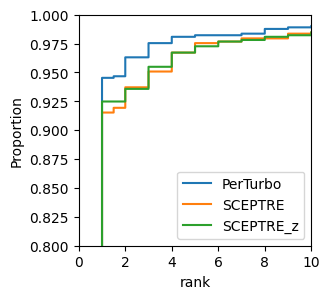

In [134]:
with plt.rc_context({"figure.figsize": [3,3]}):

  sns.ecdfplot(pos_controls.query('is_target'), x='perturbo_rank',stat="proportion", label="PerTurbo")
  sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_p_rank',stat="proportion", label="SCEPTRE")
  sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_z_rank',stat="proportion", label="SCEPTRE_z")
  plt.legend()
  # plt.title("eCDF")
  # plt.semilogy()
  plt.xlabel("rank")
  plt.xlim([0,10])
  plt.ylim(0.8, 1)
  plt.show()

0.9446816254957008 0.9234061231976527


Text(0.5, 1.0, 'perturbo vs. SCEPTRE p-values')

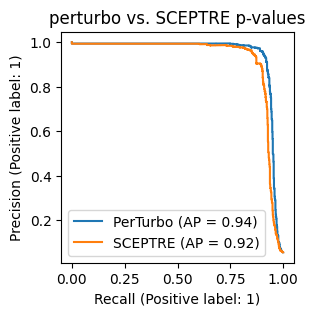

In [137]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve

with plt.rc_context({"figure.figsize": [3,3]}):
  roc = PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], 1-pos_controls['p_value'], name="PerTurbo")
  PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], 1-pos_controls['SCEPTRE_p_value'], ax=roc.ax_, name="SCEPTRE")

precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['z_value'])
score1=average_precision_score(pos_controls['is_target'], 1-pos_controls['p_value'])
score2=average_precision_score(pos_controls['is_target'], 1-pos_controls['SCEPTRE_p_value'])
print(score1, score2)
plt.title("perturbo vs. SCEPTRE p-values")
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)


0.9484097605582728 0.9304176453265475


Text(0.5, 1.0, 'z-values')

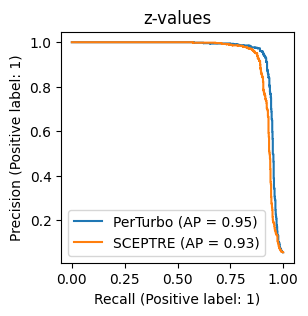

In [139]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve

with plt.rc_context({"figure.figsize": [3,3]}):
  roc = PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], -pos_controls['z_value'], name="PerTurbo")
  PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], -pos_controls['SCEPTRE_z_value'], ax=roc.ax_, name="SCEPTRE")


precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['z_value'])
score1=average_precision_score(pos_controls['is_target'], -pos_controls['z_value'])
score2=average_precision_score(pos_controls['is_target'], -pos_controls['SCEPTRE_z_value'])
print(score1, score2)
plt.title('z-values')
# plt.title()
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)


In [121]:
# plt.plot(np.log(threshold), precision[:-1])

In [122]:
import ipywidgets as widgets
from IPython.display import display

# guide_1 = f"{plot_gene}_TSS|1"
# guide_2 = f"{plot_gene}_TSS|2"

gene_select = widgets.Dropdown(
    options=sorted(mdata['rna'].var_names),
    value=mdata['rna'].var_names[0],
    # rows=10,
    description='Gene',
    disabled=False
)


guide_select = widgets.Dropdown(
    options=sorted(mdata['grna'].var_names),
    value=mdata['grna'].var_names[0],
    # rows=10,
    description='Guide',
    disabled=False
)

display(gene_select, guide_select)

Dropdown(description='Gene', index=5611, options=('A4GALT', 'AAAS', 'AACS', 'AARS2', 'AARSD1', 'AASDH', 'AATK'…

Dropdown(description='Guide', options=('ACTB_TSS|1', 'ACTB_TSS|2', 'ACTG1_TSS|1', 'ACTG1_TSS|2', 'ACYP1_TSS|1'…

In [123]:
import scanpy as sc

# plot_guides = ['TMED10_TSS|1','TMED10_TSS|2']
# plot_genes = ['TMED10', 'KDELR2','KDELR3','SEC13', 'YIF1A', 'CALU', 'YIPF2', 'SDF2L1', 'MANF']

plot_genes = [gene_select.value]
plot_guides = [guide_select.value]


counts_df = mdata["rna"][:, plot_genes].to_df()
guide_obs = mdata["grna"][:, plot_guides].X.sum(axis=1).copy().astype(bool)
counts_df['guide_obs']=guide_obs


# mdata['rna'].obs['TMED10_TSS'] = guide_obs
# mdata['rna'].obs['TMED10_TSS']=mdata['rna'].obs['TMED10_TSS'].astype("category")
# # mdata['rna'].raw = mdata['rna']
# # sc.pp.normalize_total(mdata['rna'])
# with plt.rc_context({'figure.dpi':200}):
#   sc.pl.dotplot(mdata['rna'], plot_genes, groupby='TMED10_TSS', title='TMED10_TSS')

(0.0, 50.0)

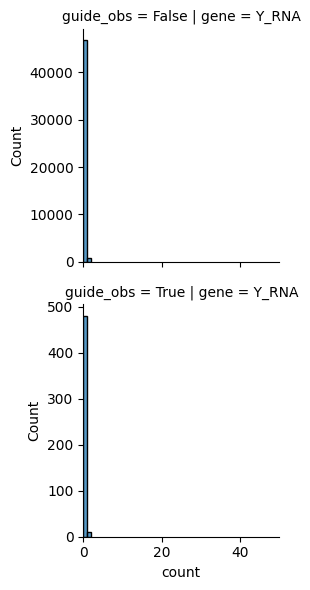

In [124]:
# plot_gene = gene_select.value
# plot_guide = guide_select.value
# print(plot_gene, plot_guide)

# plot_df = pd.DataFrame({"count": counts, "has_guide": guide_obs})
plot_df = counts_df.melt(id_vars='guide_obs',var_name='gene',value_name='count')
g = sns.FacetGrid(plot_df, col="gene", row="guide_obs",sharey=False)
g.map_dataframe(
    sns.histplot,
    x="count", binwidth=1,
    hue_order=[False,True],
    # log_scale=[False,True]
)
plt.xlim(0,50)
# plt.semilogy()

# sns.histplot(
#     plot_df.query('has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# plt.show()
# sns.histplot(
#     plot_df.query('not has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# # plt.xlim(0, 50)
# g.title(f"gene: {plot_gene}, guide: {plot_guide}")
# plt.show()



In [125]:
!pwd

/work/data/PROJECTS/2022_05_scPower


In [126]:
import altair as alt

alt.Chart(subset_results).mark_point().encode(
  x='z_value',
  y='SCEPTRE_z_value',
  color='is_target',
  tooltip=['guide','gene', 'z_value', 'SCEPTRE_z_value'] 
).interactive()


alt.Chart(...)

# # selection = alt.selection_single(fields=['gene', 'guide'])

alt.Chart(subset_results).mark_point().encode(
  x=alt.X('p_value', scale=alt.Scale(type="log", domain=[min_p_value, 1])),
  y=alt.Y('SCEPTRE_p_value', scale=alt.Scale(type="log", domain=[min_p_value, 1])),
  color='is_target',
  tooltip=['guide','gene', 'z_value', 'SCEPTRE_z_value'] 
).interactive()




In [41]:
# scpower_df.to_csv(f"{data_dir}/scpower_results.csv")